# 04 - Allen-Cahn Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \varepsilon^2 u_{xx} + u - u^3$, $\varepsilon = 0.01$

**IC:** $u(x,0) = x^2 \cos(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 128, 128, 128, 128, 128, 1]` | **Epochs:** 10000

**Note:** Allen-Cahn is the hardest test. Stiff PDE with sharp interface.
Vanilla PINN is known to fail here. This is AC-PINN's strongest showcase.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    AllenCahnFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'allen_cahn'
LAYERS     = [2, 128, 128, 128, 128, 128, 1]
EPOCHS     = 10000
PDE_PARAMS = {'epsilon': 0.01}
RESULTS    = '../results/allen_cahn/'
FIGURES    = '../figures/allen_cahn/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

AllenCahnFDM solved in 1.9181s


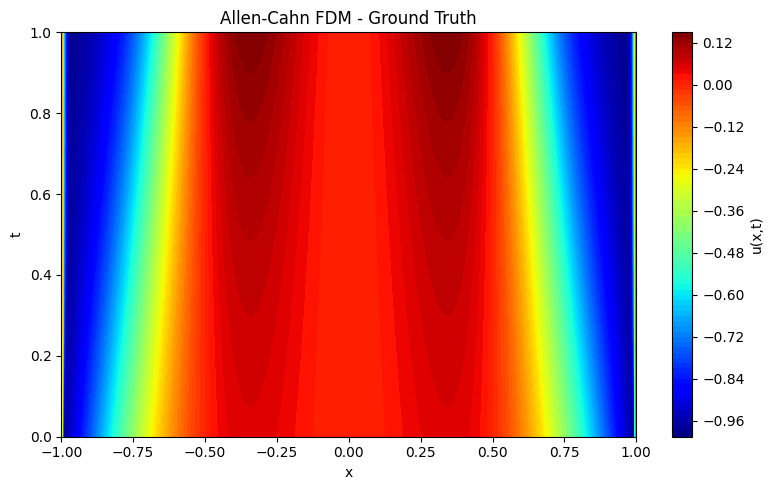

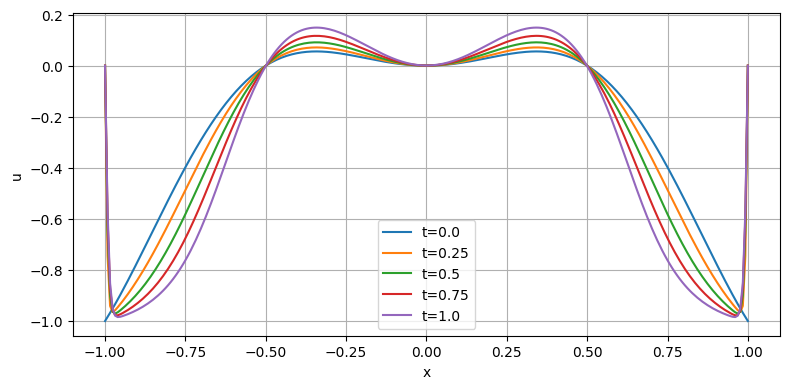

In [2]:
fdm = AllenCahnFDM(nx=256, nt=5000, epsilon=0.01)
fdm.solve()
fdm.plot_solution(title='Allen-Cahn FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
# Allen-Cahn needs more collocation points due to stiffness
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=10000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=3000,  noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Allen-Cahn | Vanilla Clean | Epoch     0/10000] Total: 0.626974 | IC: 0.144497 | BC: 0.087670 | PDE: 0.039481


[Allen-Cahn | Vanilla Clean | Epoch  1000/10000] Total: 0.128943 | IC: 0.121899 | BC: 0.003938 | PDE: 0.000311


[Allen-Cahn | Vanilla Clean | Epoch  2000/10000] Total: 0.130245 | IC: 0.124084 | BC: 0.004663 | PDE: 0.000150


[Allen-Cahn | Vanilla Clean | Epoch  3000/10000] Total: 0.128454 | IC: 0.121195 | BC: 0.003796 | PDE: 0.000346


...

[Allen-Cahn | Vanilla Clean | Epoch  6000/10000] Total: 0.048437 | IC: 0.040147 | BC: 0.003748 | PDE: 0.000454


[Allen-Cahn | Vanilla Clean | Epoch  7000/10000] Total: 0.034409 | IC: 0.023831 | BC: 0.006994 | PDE: 0.000358


[Allen-Cahn | Vanilla Clean | Epoch  8000/10000] Total: 0.019724 | IC: 0.017373 | BC: 0.000474 | PDE: 0.000188


[Allen-Cahn | Vanilla Clean | Epoch  9000/10000] Total: 0.020294 | IC: 0.015079 | BC: 0.003662 | PDE: 0.000155



Training complete in 276.59s


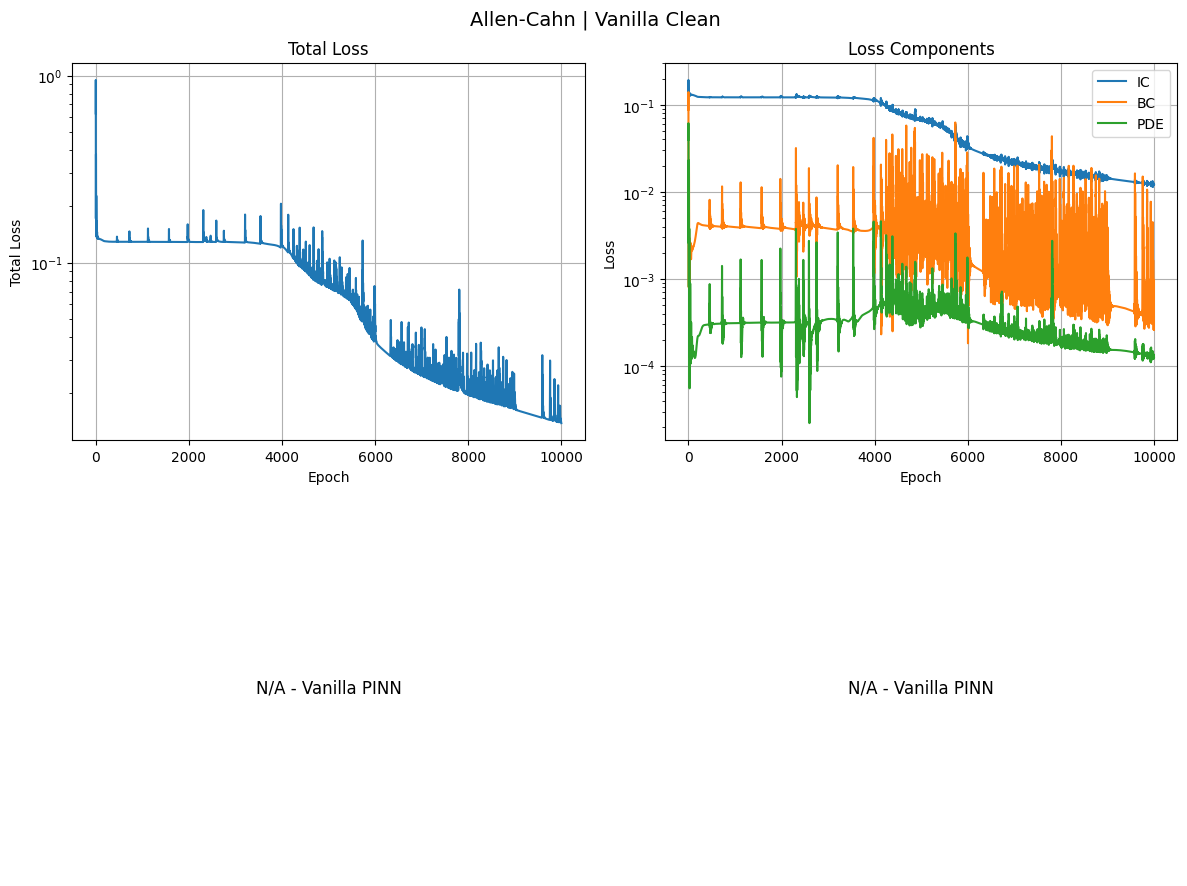

Saved: ../figures/allen_cahn/vanilla_clean_training.png
Saved: ../figures/allen_cahn/vanilla_clean_training.csv


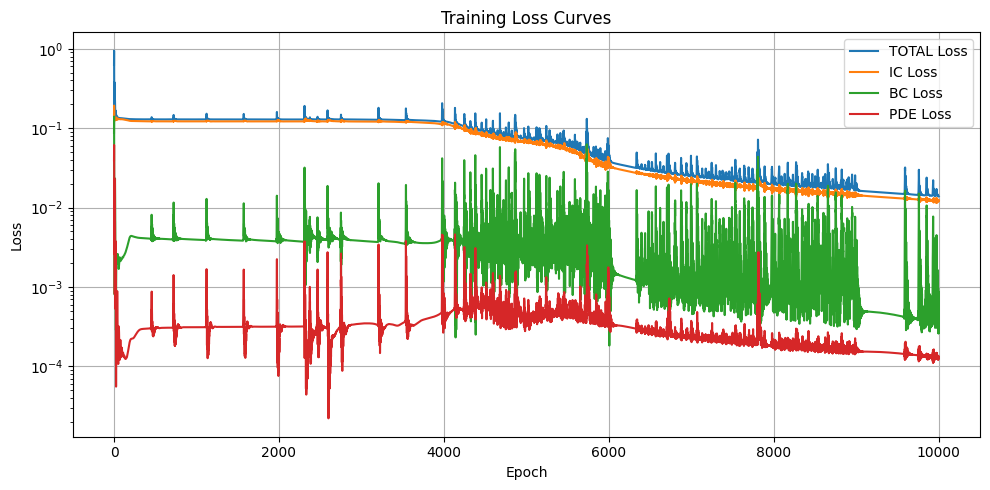

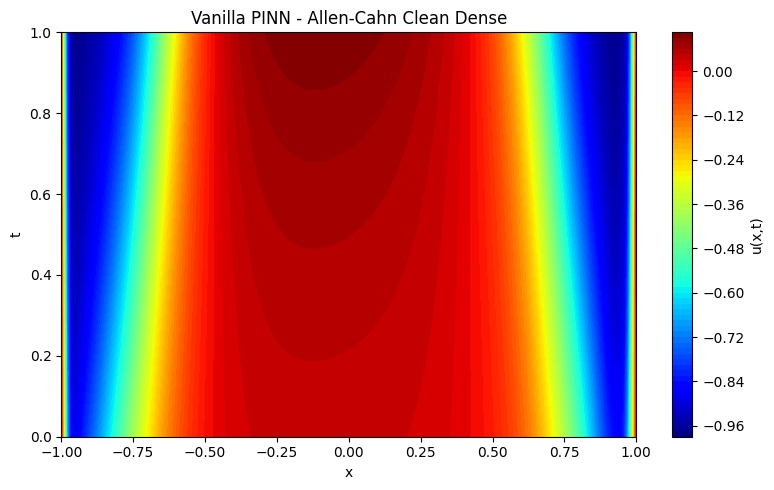

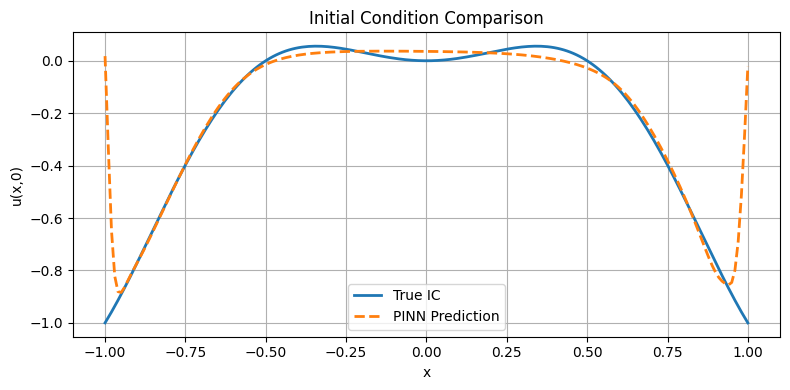

Saved: ../results/allen_cahn/vanilla_clean_history.npy


In [4]:
# Higher lambda_pde for stiff PDE
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Allen-Cahn | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Allen-Cahn Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse
⚠️ Vanilla PINN typically fails here on Allen-Cahn.

[Allen-Cahn | Vanilla Noisy | Epoch     0/10000] Total: 0.222897 | IC: 0.160220 | BC: 0.031515 | PDE: 0.003116


[Allen-Cahn | Vanilla Noisy | Epoch  1000/10000] Total: 0.171356 | IC: 0.147896 | BC: 0.018931 | PDE: 0.000453


[Allen-Cahn | Vanilla Noisy | Epoch  2000/10000] Total: 0.175861 | IC: 0.149349 | BC: 0.023983 | PDE: 0.000253


[Allen-Cahn | Vanilla Noisy | Epoch  3000/10000] Total: 0.143990 | IC: 0.113653 | BC: 0.025421 | PDE: 0.000492


[Allen-Cahn | Vanilla Noisy | Epoch  4000/10000] Total: 0.130944 | IC: 0.102572 | BC: 0.020978 | PDE: 0.000739


...

[Allen-Cahn | Vanilla Noisy | Epoch  6000/10000] Total: 0.127031 | IC: 0.105304 | BC: 0.017335 | PDE: 0.000439


[Allen-Cahn | Vanilla Noisy | Epoch  7000/10000] Total: 0.102742 | IC: 0.075615 | BC: 0.019211 | PDE: 0.000792


[Allen-Cahn | Vanilla Noisy | Epoch  8000/10000] Total: 0.059195 | IC: 0.033552 | BC: 0.016160 | PDE: 0.000948


[Allen-Cahn | Vanilla Noisy | Epoch  9000/10000] Total: 0.025510 | IC: 0.008121 | BC: 0.014946 | PDE: 0.000244



Training complete in 136.67s


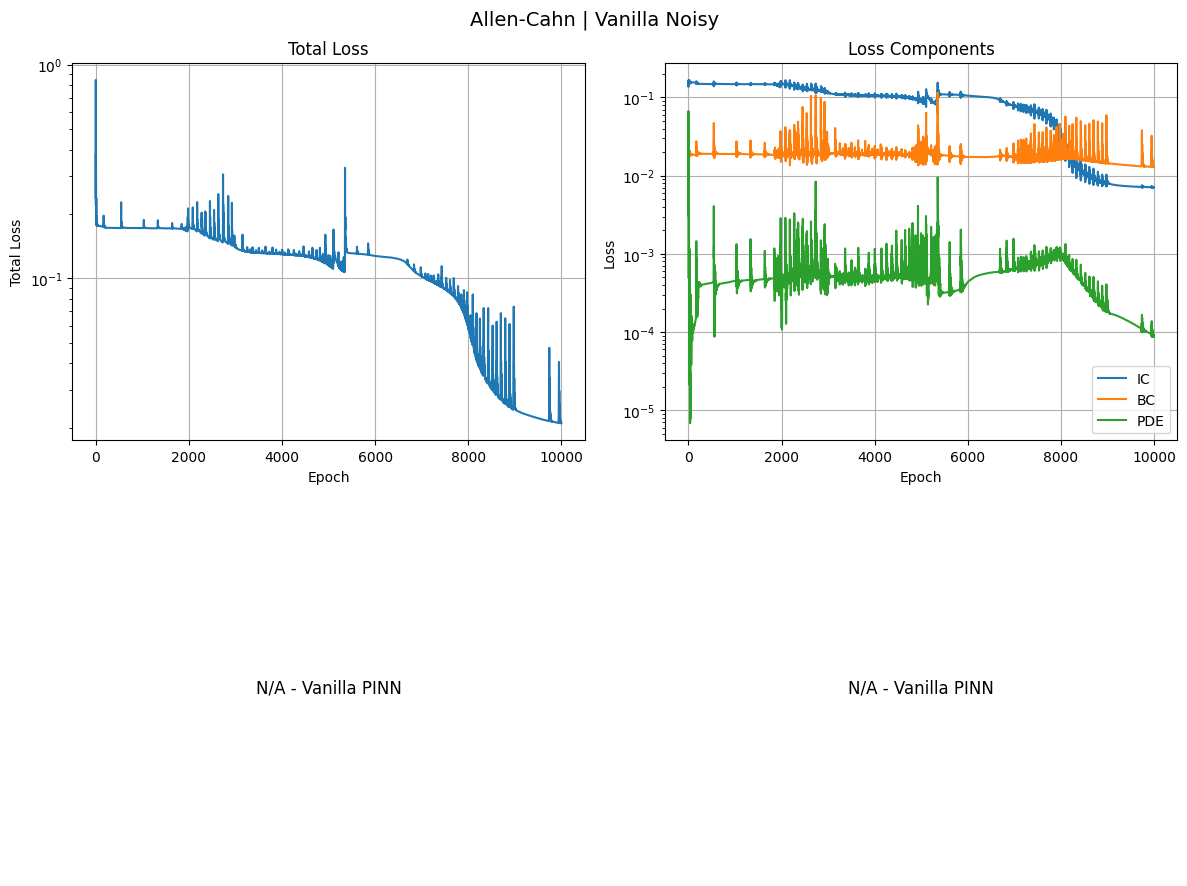

Saved: ../figures/allen_cahn/vanilla_noisy_training.png
Saved: ../figures/allen_cahn/vanilla_noisy_training.csv


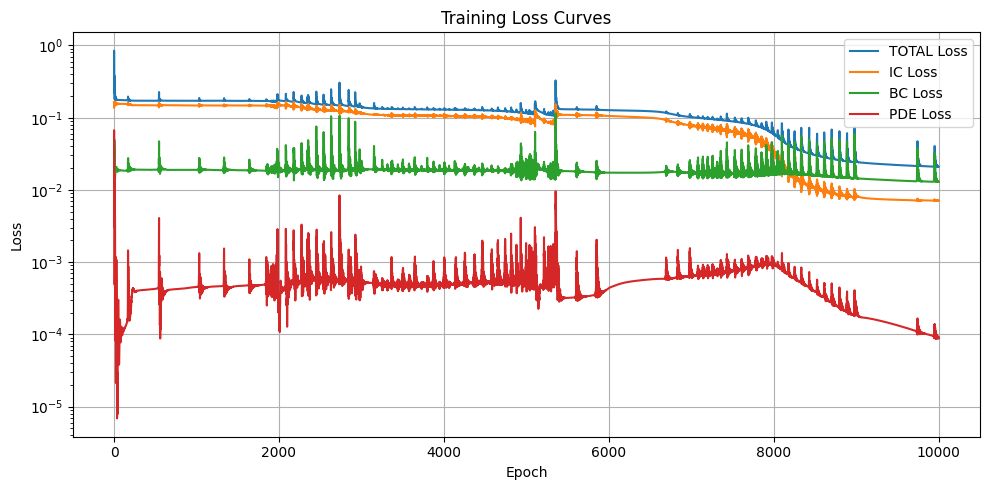

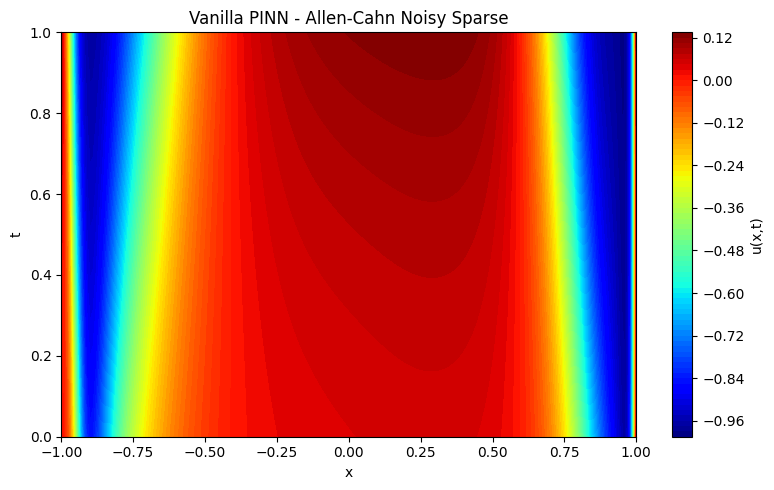

Saved: ../results/allen_cahn/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=10.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Allen-Cahn | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Allen-Cahn Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Allen-Cahn | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 0.196306 | IC: 0.142633 | BC: 0.049597 | PDE: 0.000815 | λ=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.091380 | IC: 0.006492 | BC: 0.029534 | PDE: 0.002163 | λ=(4.79,1.59,6.19)


[Allen-Cahn | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.013632 | IC: 0.000618 | BC: 0.006259 | PDE: 0.000002 | λ=(2.38,1.94,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.009599 | IC: 0.000539 | BC: 0.005325 | PDE: 0.000000 | λ=(3.57,1.44,10.00)


[Allen-Cahn | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.007876 | IC: 0.000050 | BC: 0.006308 | PDE: 0.000000 | λ=(6.56,1.20,10.00)


...

[Allen-Cahn | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.023954 | IC: 0.000041 | BC: 0.008028 | PDE: 0.000004 | λ=(0.10,2.98,0.10)


[Allen-Cahn | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.143955 | IC: 0.049044 | BC: 0.001121 | PDE: 0.000001 | λ=(2.93,0.10,0.10)


[Allen-Cahn | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.175603 | IC: 0.050622 | BC: 0.067296 | PDE: 0.055103 | λ=(0.88,1.17,0.96)


[Allen-Cahn | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.397028 | IC: 0.132734 | BC: 0.000153 | PDE: 0.000254 | λ=(2.99,0.10,0.10)



AC-PINN training complete in 299.13s


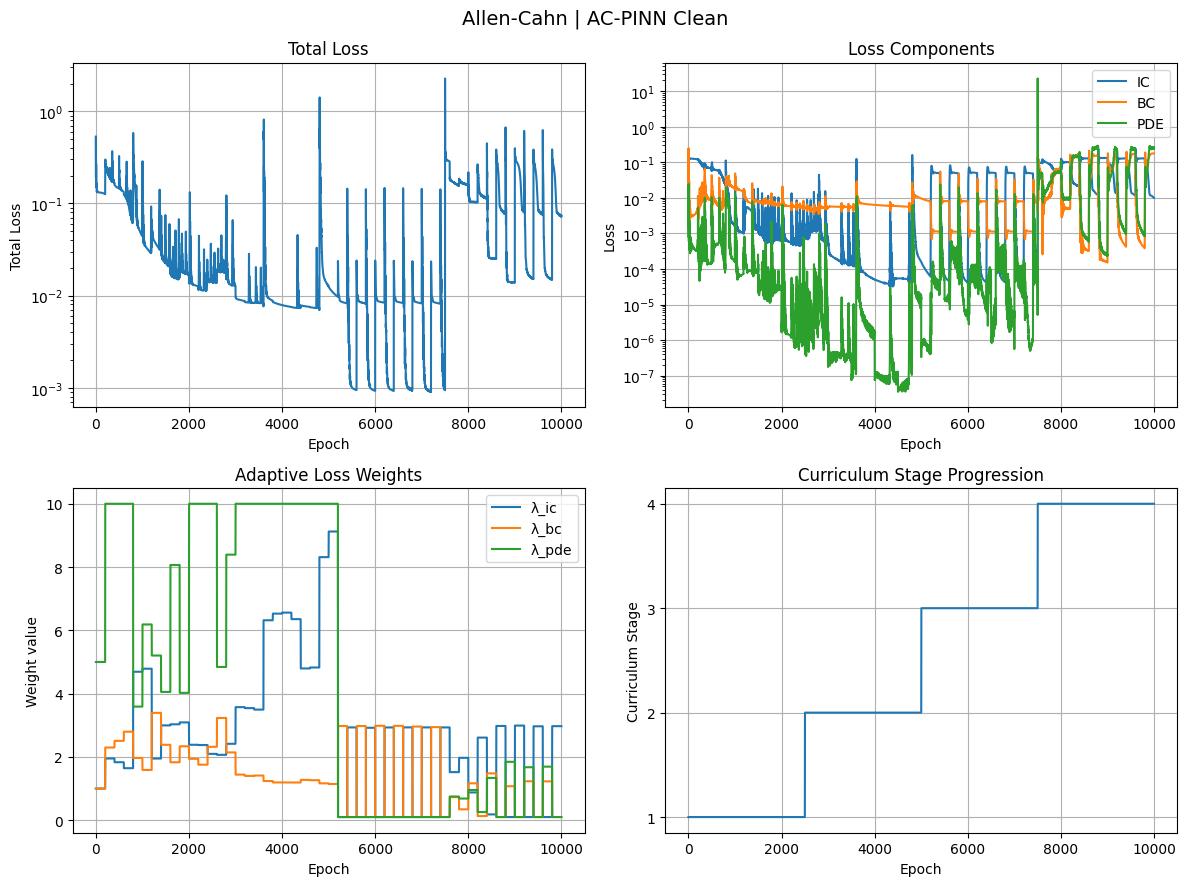

Saved: ../figures/allen_cahn/acpinn_clean_training.png
Saved: ../figures/allen_cahn/acpinn_clean_training.csv


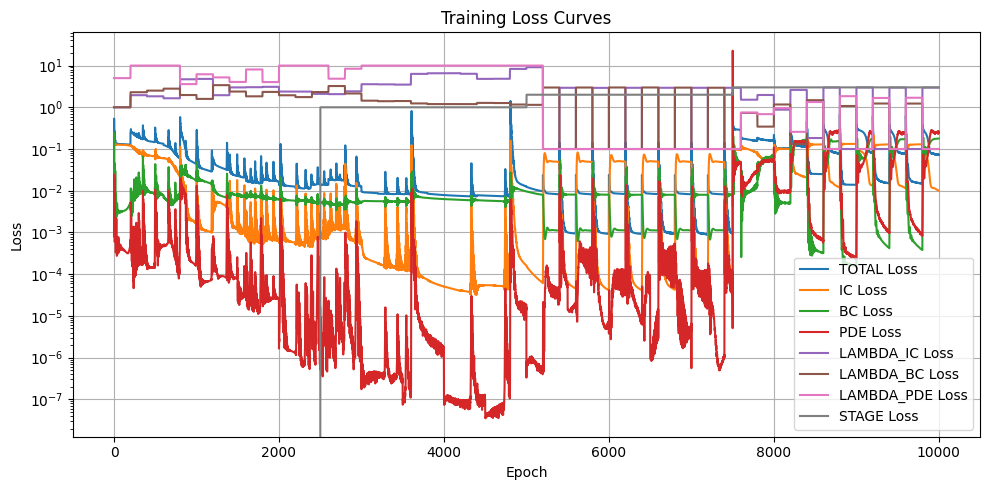

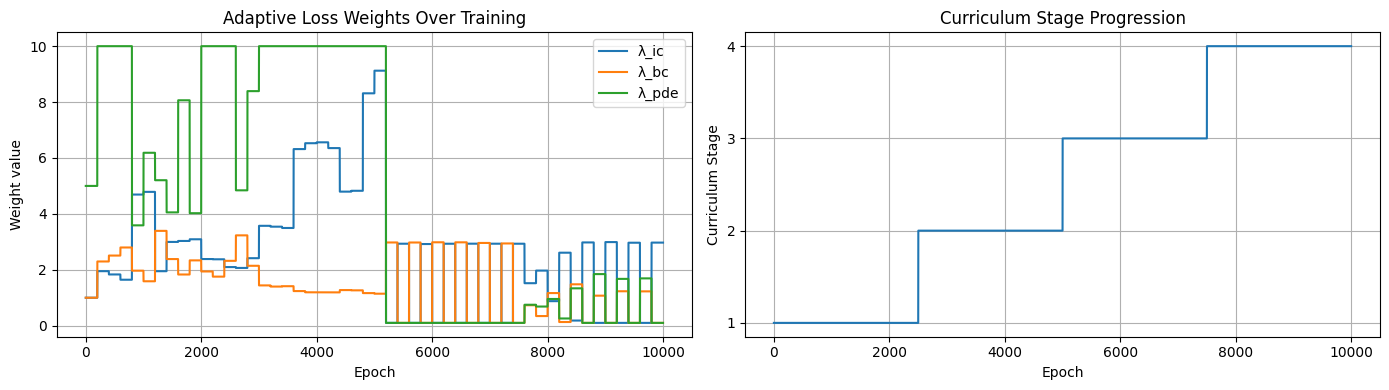

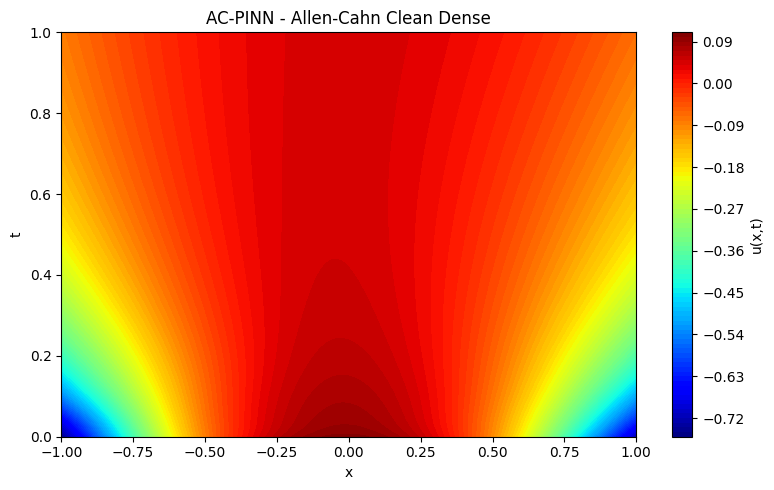

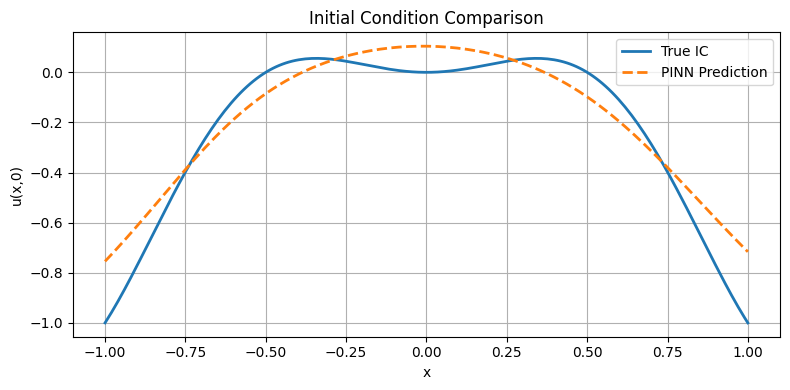

Saved: ../results/allen_cahn/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Allen-Cahn | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Allen-Cahn Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse
This is where AC-PINN should demonstrate its biggest advantage.

[Allen-Cahn | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.211765 | IC: 0.150837 | BC: 0.058899 | PDE: 0.000406 | λ=(1.00,1.00,5.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.039671 | IC: 0.007976 | BC: 0.009067 | PDE: 0.000087 | λ=(2.82,1.80,10.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.039165 | IC: 0.006673 | BC: 0.007338 | PDE: 0.000016 | λ=(4.18,1.51,10.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.026770 | IC: 0.005654 | BC: 0.006264 | PDE: 0.000068 | λ=(2.13,2.24,10.00)


[Allen-Cahn | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.030289 | IC: 0.005303 | BC: 0.006176 | PDE: 0.000036 | λ=(2.08,3.09,5.13)


...

[Allen-Cahn | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.017738 | IC: 0.005808 | BC: 0.006425 | PDE: 0.000495 | λ=(1.37,1.51,0.12)


[Allen-Cahn | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.016336 | IC: 0.005461 | BC: 0.006119 | PDE: 0.000933 | λ=(1.31,1.47,0.22)


[Allen-Cahn | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 1.036718 | IC: 0.019074 | BC: 0.032861 | PDE: 0.388097 | λ=(0.13,0.22,2.65)


[Allen-Cahn | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.441073 | IC: 0.159359 | BC: 0.014571 | PDE: 0.000252 | λ=(2.74,0.25,0.10)



AC-PINN training complete in 158.41s


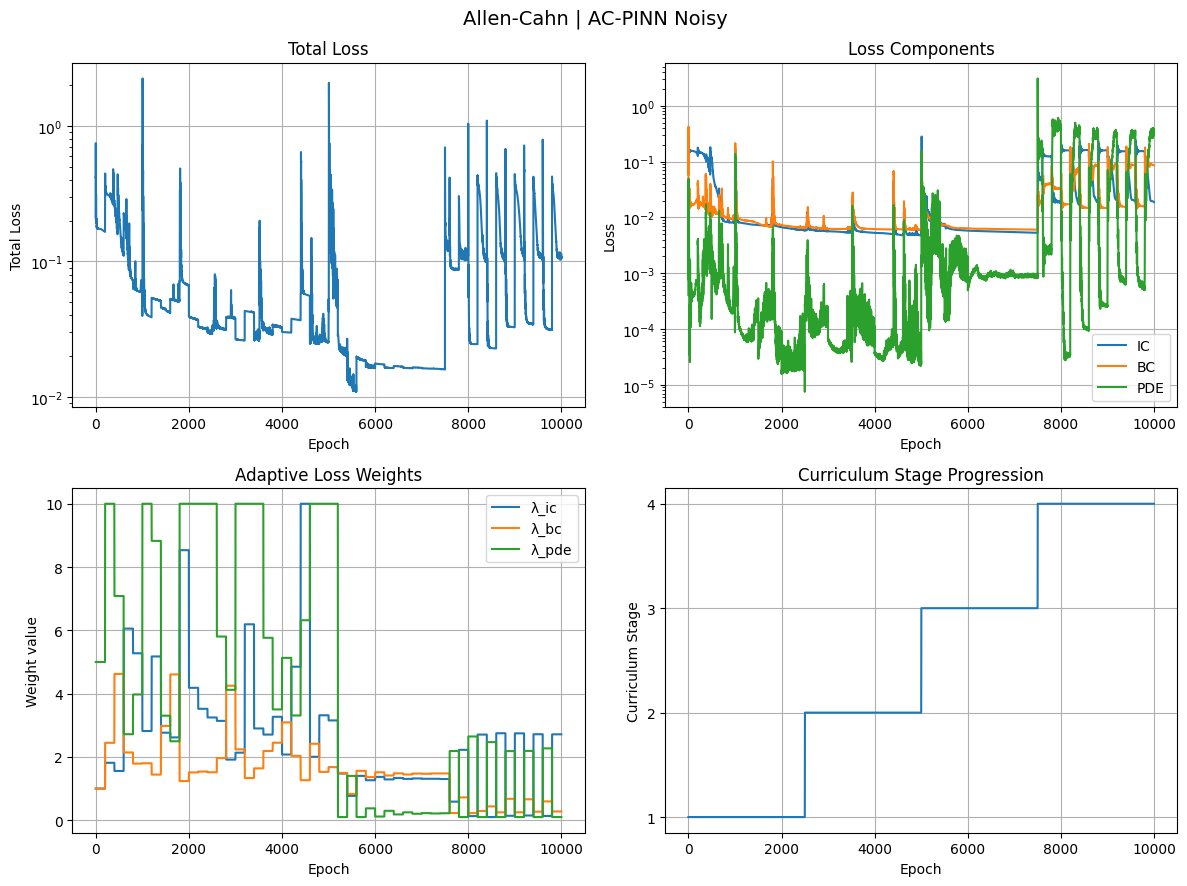

Saved: ../figures/allen_cahn/acpinn_noisy_training.png
Saved: ../figures/allen_cahn/acpinn_noisy_training.csv


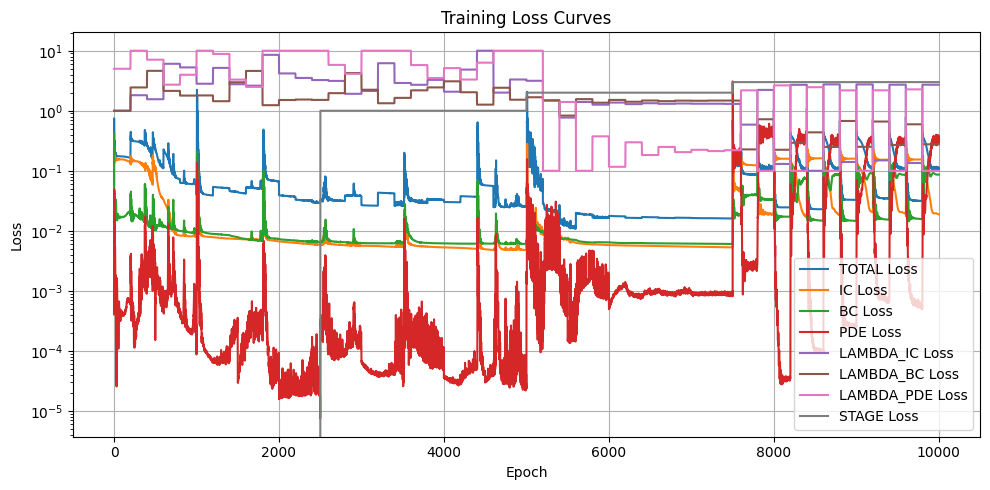

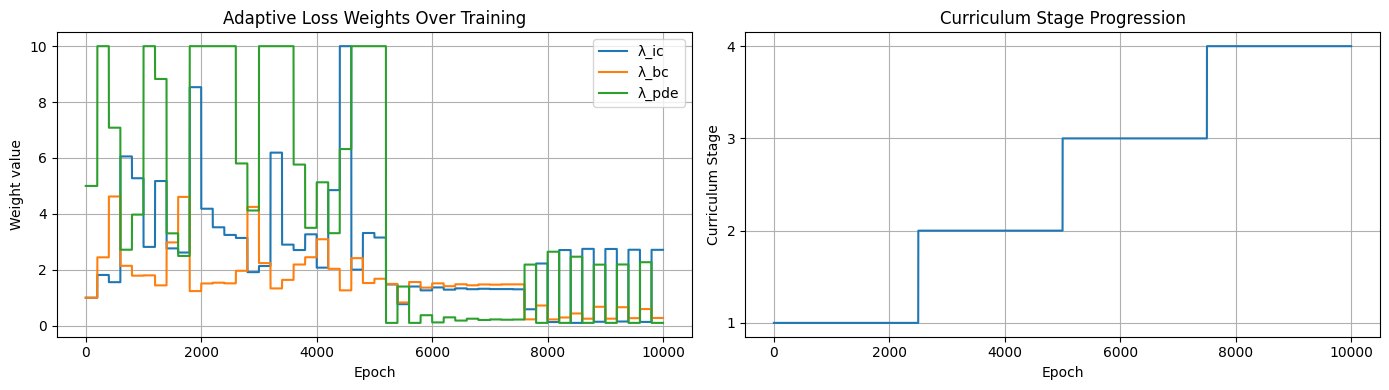

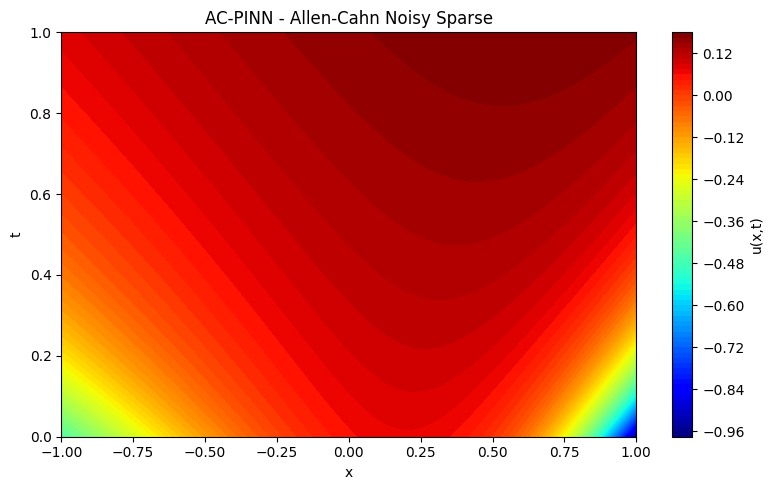

Saved: ../results/allen_cahn/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both',
                         N_pool=30000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Allen-Cahn | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Allen-Cahn | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Allen-Cahn Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.143559   1.017695   0.035595   0.062932
  Vanilla (noisy)             0.316406   1.047791   0.077888   0.138703
  AC-PINN (clean)             0.812069   0.922218   0.229725   0.355987
  AC-PINN (noisy)             1.040699   1.153148   0.309040   0.456213


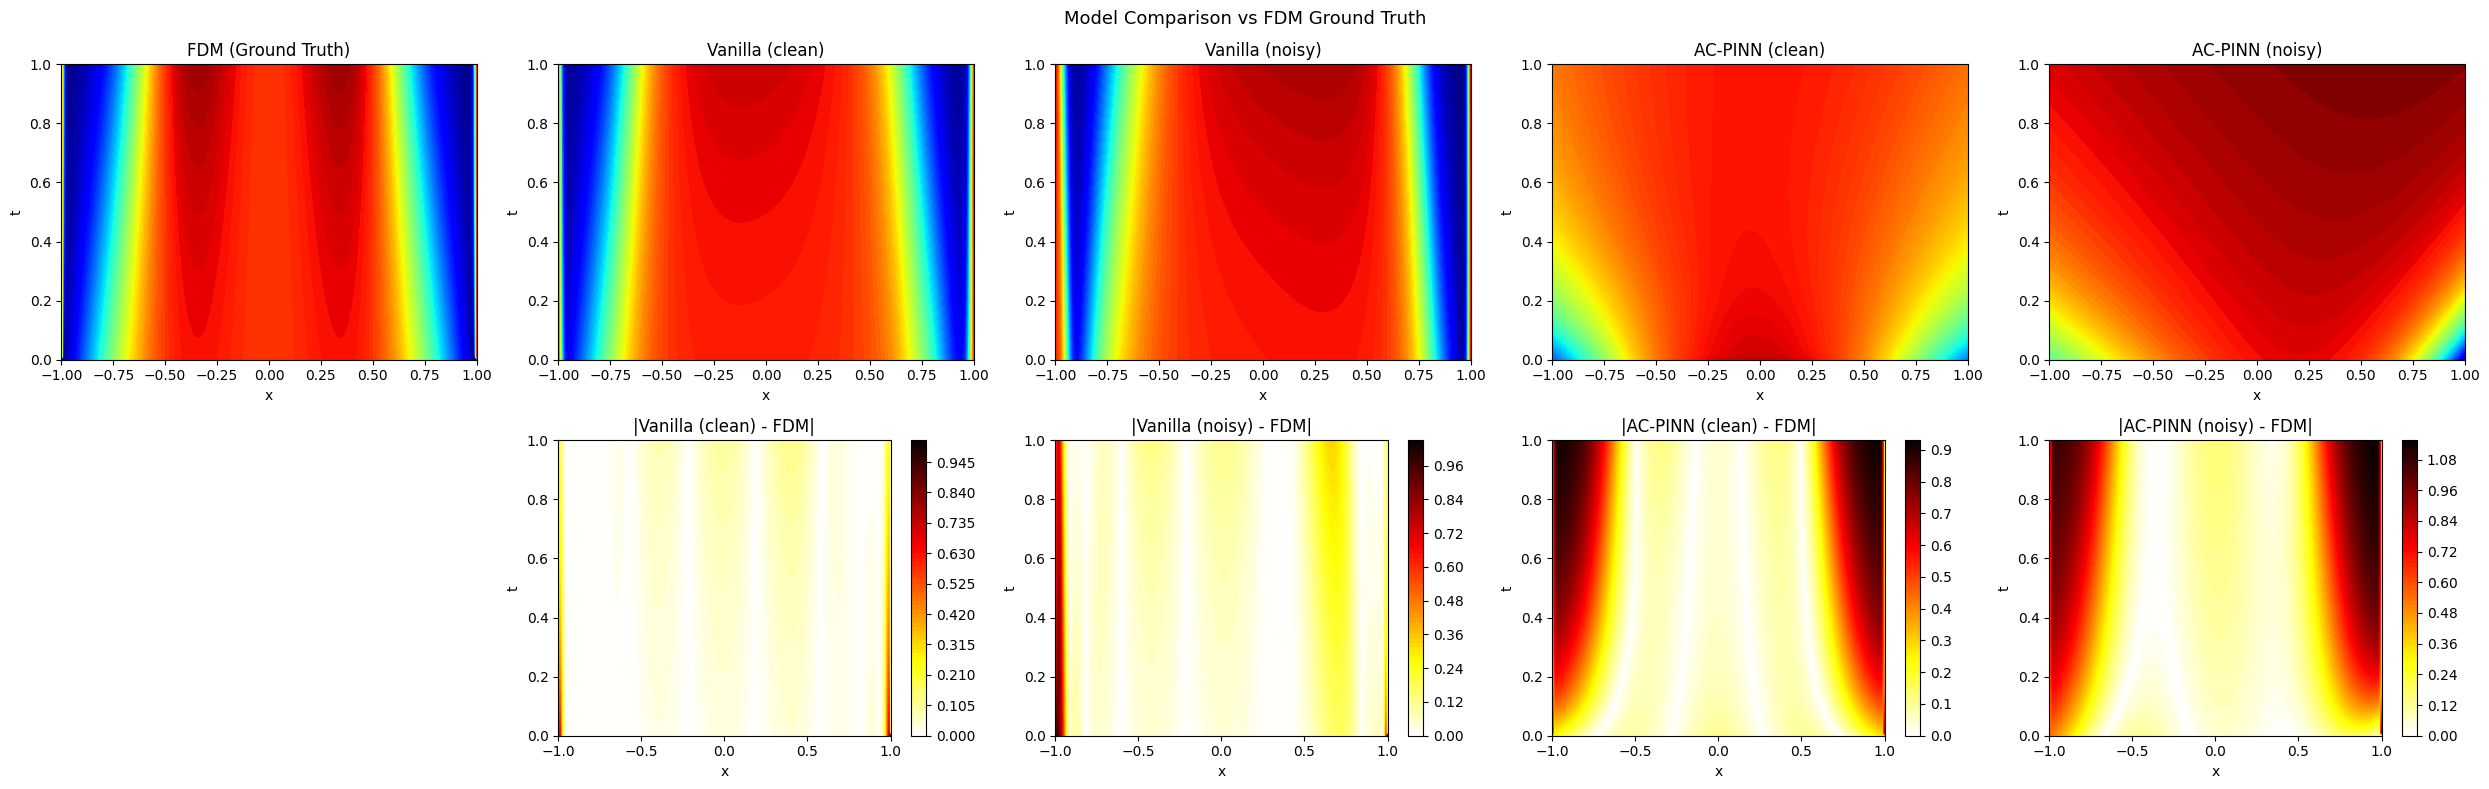

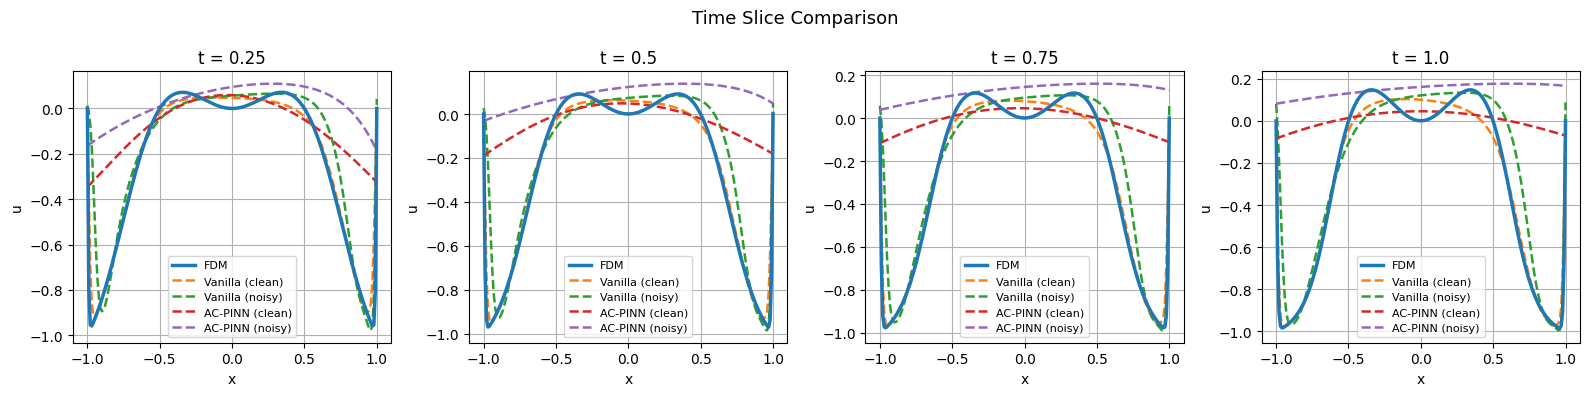

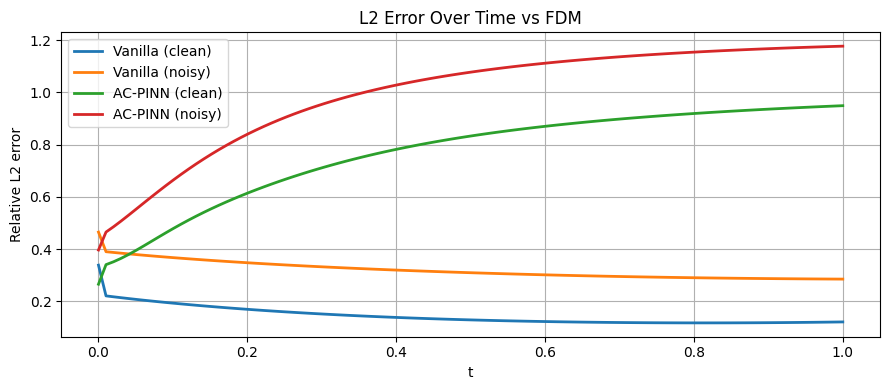

Saved: ../results/allen_cahn/benchmark_metrics.npy
Allen-Cahn experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Allen-Cahn experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=5000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, lambda_pde=10.0)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Allen-Cahn noise study complete.')


--- ε=0.05 ---


[Epoch     0/5000] Total: 0.591497 | IC: 0.160854 | BC: 0.155205 | PDE: 0.027544


[Epoch  2500/5000] Total: 0.124157 | IC: 0.112330 | BC: 0.009061 | PDE: 0.000277



Training complete in 86.70s
[Epoch     0/5000] Stage 1/4 | Total: 0.127733 | IC: 0.119624 | BC: 0.007746 | PDE: 0.000073 | λ=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 2/4 | Total: 0.015569 | IC: 0.002428 | BC: 0.002987 | PDE: 0.000005 | λ=(3.77,2.14,3.74)


...


AC-PINN training complete in 88.18s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.794291   0.974870   0.248946   0.348194
  AC-PINN ε=0.1               0.979001   0.990372   0.288530   0.429166

--- ε=0.2 ---
[Epoch     0/5000] Total: 0.268482 | IC: 0.125368 | BC: 0.076212 | PDE: 0.006690


[Epoch  2500/5000] Total: 0.178392 | IC: 0.086120 | BC: 0.069230 | PDE: 0.002304



Training complete in 81.85s
[Epoch     0/5000] Stage 1/4 | Total: 0.193024 | IC: 0.121321 | BC: 0.070732 | PDE: 0.000194 | λ=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 2/4 | Total: 0.233589 | IC: 0.042495 | BC: 0.063939 | PDE: 0.000048 | λ=(2.78,1.80,10.00)



AC-PINN training complete in 88.19s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.459016   1.069122   0.109629   0.201219
  AC-PINN ε=0.2               0.770576   1.206568   0.217735   0.337798
Saved: ../results/allen_cahn/noise_study_metrics.npy
Allen-Cahn noise study complete.
